In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, silhouette_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from xgboost import XGBClassifier

In [2]:
!kaggle datasets download -d rohan0301/unsupervised-learning-on-country-data
!unzip -o unsupervised-learning-on-country-data.zip

import os
print(os.listdir("."))

Dataset URL: https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data
License(s): MIT
100% 5.21k/5.21k [00:00<00:00, 2.13MB/s]

Archive:  unsupervised-learning-on-country-data.zip
  inflating: Country-data.csv        
  inflating: data-dictionary.csv     
['.config', 'Country-data.csv', 'unsupervised-learning-on-country-data.zip', 'data-dictionary.csv', 'sample_data']


In [ ]:
# Loading the dadta
df = pd.read_csv("Country-data.csv")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (167, 10)

First 5 rows:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


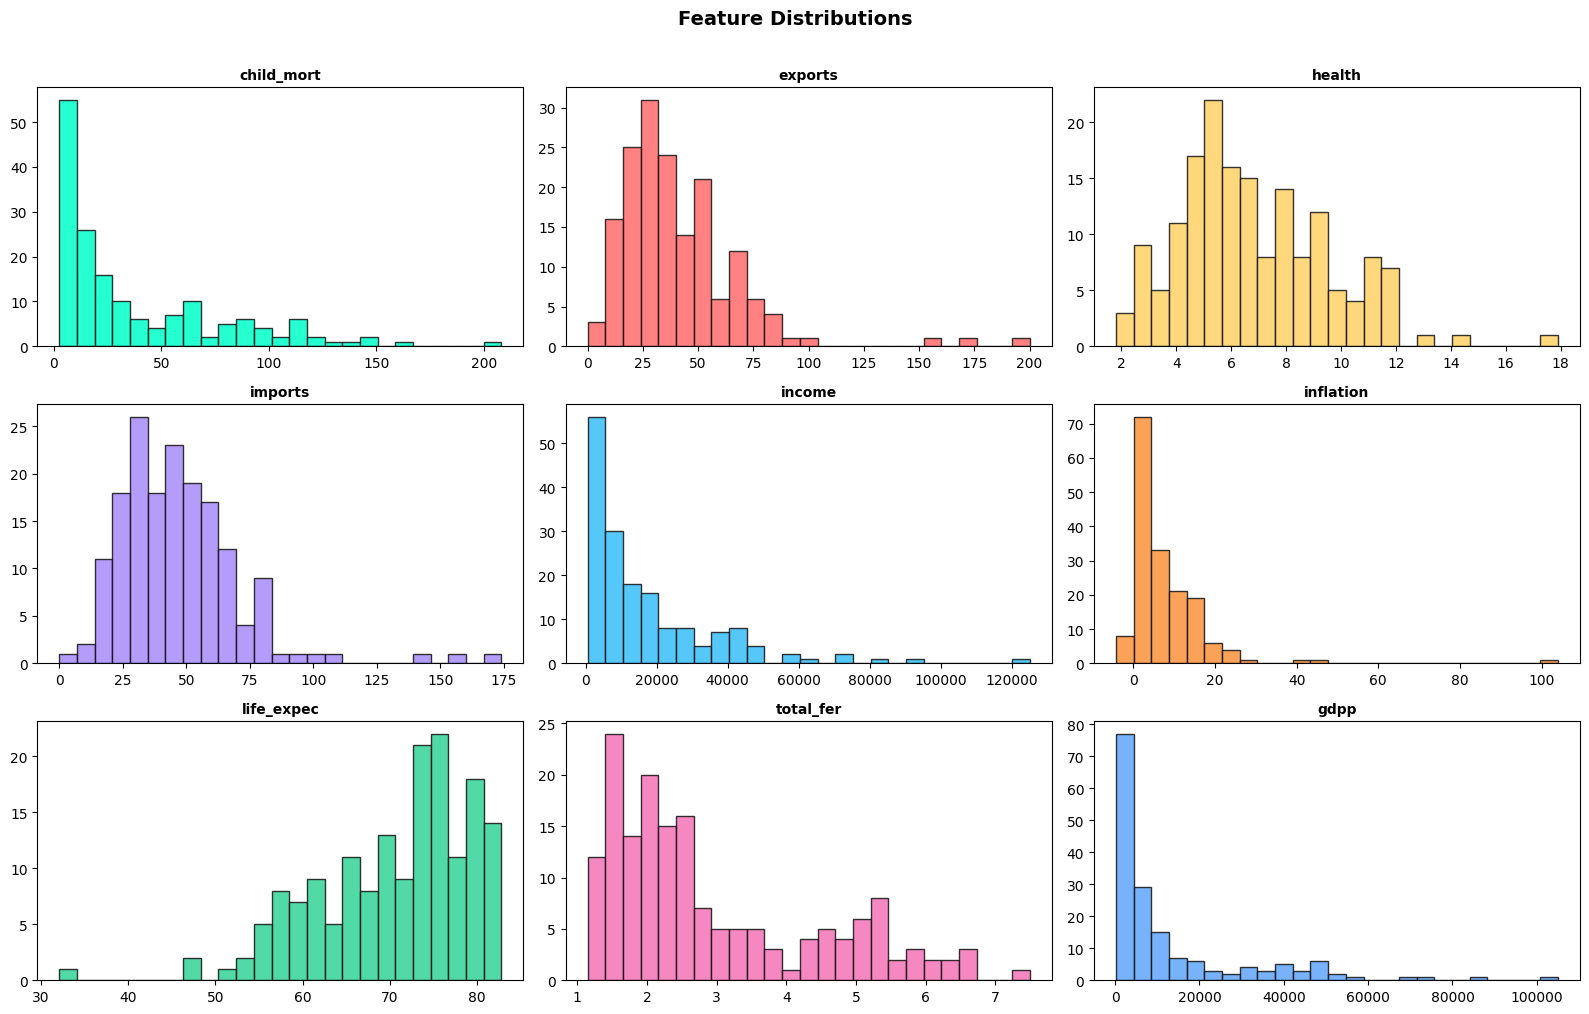

In [ ]:
features = ["child_mort", "exports", "health", "imports", "income", "inflation", "life_expec", "total_fer", "gdpp"]

plt.figure(figsize=(16, 10))
colors = ["#00ffc8","#ff6b6b","#ffd166","#a78bfa","#38bdf8","#fb923c","#34d399","#f472b6","#60a5fa"]

for i, (feat, clr) in enumerate(zip(features, colors)):
    plt.subplot(3, 3, i+1)
    plt.hist(df[feat], bins=25, color=clr, edgecolor="#111", alpha=0.85)
    plt.title(feat, fontsize=10, fontweight="bold")
    plt.xlabel("")

plt.suptitle("Feature Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

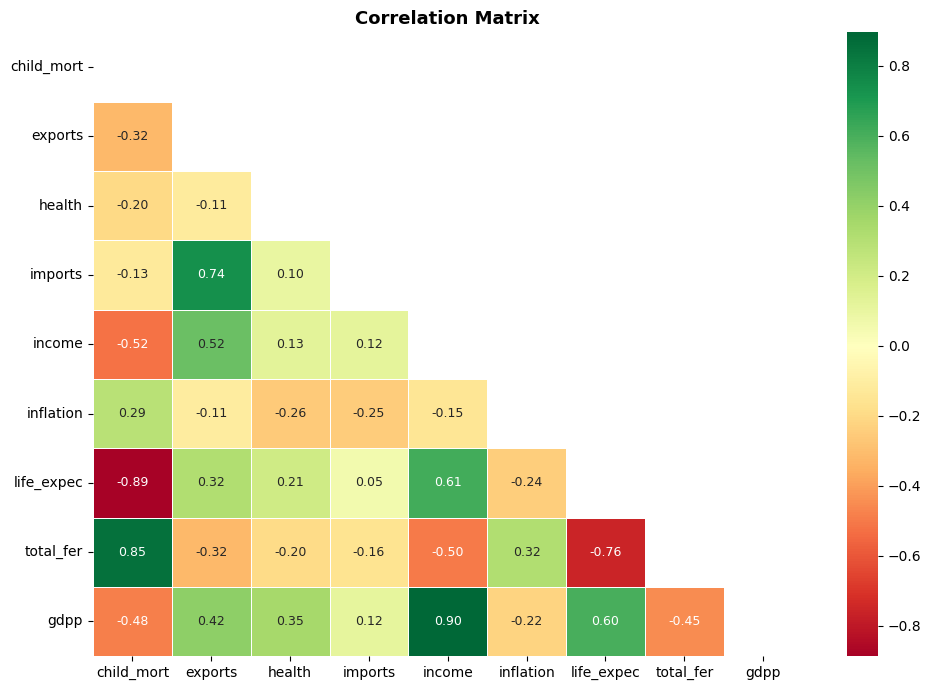

In [ ]:
plt.figure(figsize=(10, 7))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn", center=0, linewidths=0.5, annot_kws={"size": 9})

plt.title("Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

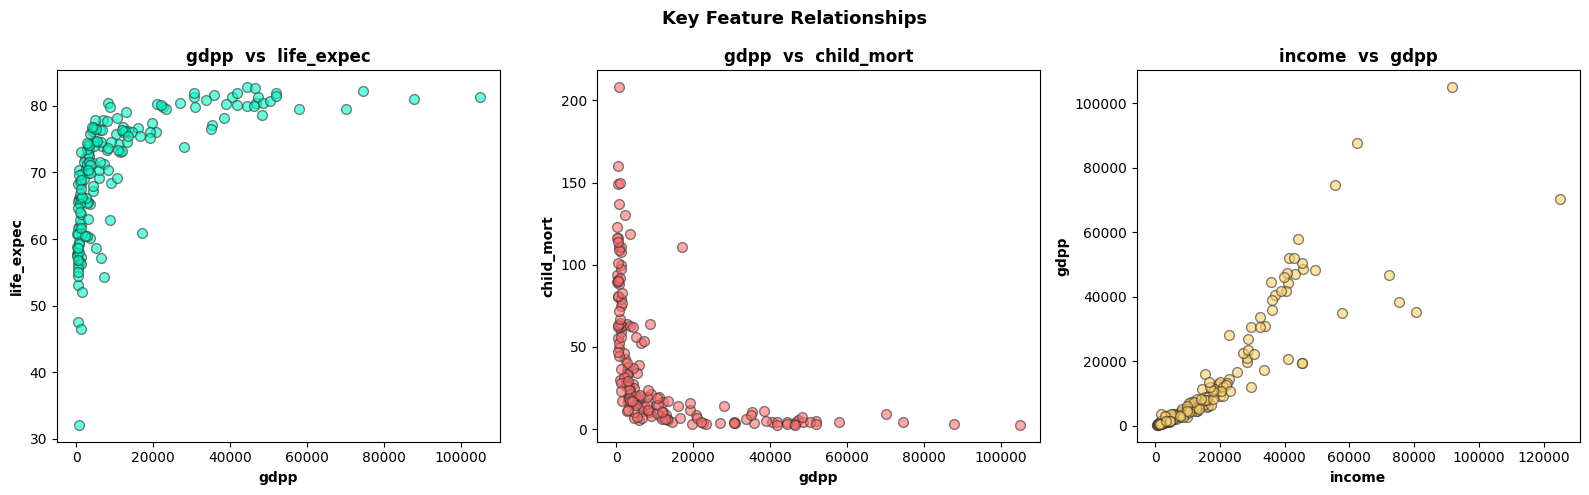

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [
    ("gdpp",      "life_expec", "#00ffc8"),
    ("gdpp",      "child_mort", "#ff6b6b"),
    ("income",    "gdpp",       "#ffd166"),
]

for ax, (x_col, y_col, clr) in zip(axes, pairs):
    ax.scatter(df[x_col], df[y_col], alpha=0.6, color=clr, edgecolors="#333", s=50)
    ax.set_xlabel(x_col, fontweight="bold")
    ax.set_ylabel(y_col, fontweight="bold")
    ax.set_title(f"{x_col}  vs  {y_col}", fontweight="bold")

plt.suptitle("Feature Relationships", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Class Distribution:
label
Developed         57
Underdeveloped    55
Developing        55
Name: count, dtype: int64


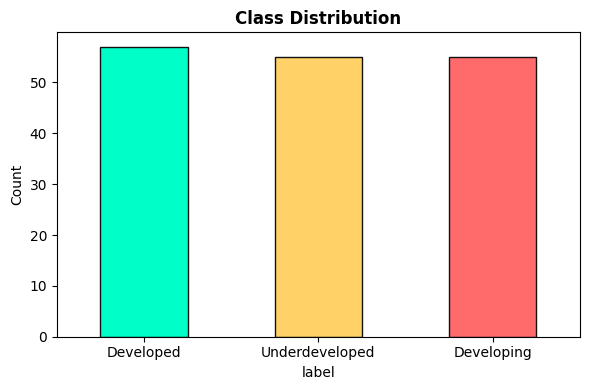

In [ ]:
# taeget Labels
df["_score"] = (
    df["gdpp"]       / df["gdpp"].max()       * 0.4 +
    df["life_expec"] / df["life_expec"].max() * 0.3 +
    (1 - df["child_mort"] / df["child_mort"].max()) * 0.2 +
    df["income"]     / df["income"].max()     * 0.1
)

q33 = df["_score"].quantile(0.33)
q66 = df["_score"].quantile(0.66)

def assign_label(score):
    if score > q66:   return "Developed"
    elif score > q33: return "Developing"
    else:             return "Underdeveloped"

df["label"] = df["_score"].apply(assign_label)
df.drop(columns=["_score"], inplace=True)

print("Class Distribution:")
print(df["label"].value_counts())

plt.figure(figsize=(6, 4))
df["label"].value_counts().plot(kind="bar", color=["#00ffc8","#ffd166","#ff6b6b"],
                                edgecolor="#111")
plt.title("Class Distribution", fontweight="bold")
plt.xticks(rotation=0)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
X = df[features].copy()
y_raw = df["label"]

le = LabelEncoder()
y = le.fit_transform(y_raw)
print("Label Encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (stratified to preserve class ratios)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size : {X_train.shape[0]}")
print(f"Test  size : {X_test.shape[0]}")

Label Encoding: {'Developed': np.int64(0), 'Developing': np.int64(1), 'Underdeveloped': np.int64(2)}

Train size : 133
Test  size : 34


In [ ]:
#Train
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Test
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob, multi_class="ovr")
rf_cv  = cross_val_score(rf, X_scaled, y, cv=5, scoring="accuracy").mean()

print("=" * 45)
print("       RANDOM FOREST RESULTS")
print("=" * 45)
print(f"  Test Accuracy : {rf_acc:.4f}")
print(f"  ROC-AUC (OvR) : {rf_auc:.4f}")
print(f"  5-Fold CV Acc : {rf_cv:.4f}")
print("=" * 45)
print(classification_report(y_test, rf_pred, target_names=le.classes_))

       RANDOM FOREST RESULTS
  Test Accuracy : 0.9412
  ROC-AUC (OvR) : 0.9934
  5-Fold CV Acc : 0.9520
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00        12
    Developing       0.91      0.91      0.91        11
Underdeveloped       0.91      0.91      0.91        11

      accuracy                           0.94        34
     macro avg       0.94      0.94      0.94        34
  weighted avg       0.94      0.94      0.94        34



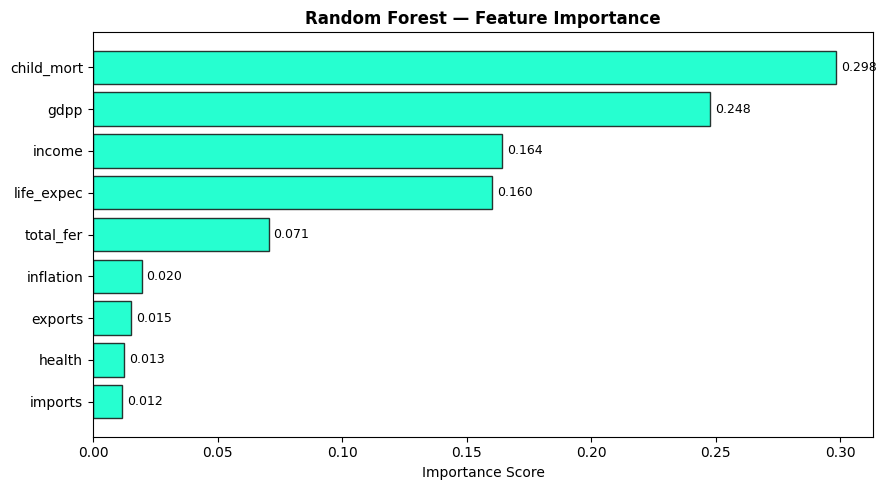

In [ ]:
# Feature Importance
fi = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(fi.index, fi.values, color="#00ffc8", edgecolor="#111", alpha=0.85)
for bar, val in zip(bars, fi.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=9)
plt.title("Random Forest — Feature Importance", fontsize=12, fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [ ]:
# Train
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)

# Test
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob, multi_class="ovr")
xgb_cv  = cross_val_score(xgb, X_scaled, y, cv=5, scoring="accuracy").mean()

print("=" * 45)
print("         XGBOOST RESULTS")
print("=" * 45)
print(f"  Test Accuracy : {xgb_acc:.4f}")
print(f"  ROC-AUC (OvR) : {xgb_auc:.4f}")
print(f"  5-Fold CV Acc : {xgb_cv:.4f}")
print("=" * 45)
print(classification_report(y_test, xgb_pred, target_names=le.classes_))

         XGBOOST RESULTS
  Test Accuracy : 0.9412
  ROC-AUC (OvR) : 1.0000
  5-Fold CV Acc : 0.9522
                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00        12
    Developing       0.85      1.00      0.92        11
Underdeveloped       1.00      0.82      0.90        11

      accuracy                           0.94        34
     macro avg       0.95      0.94      0.94        34
  weighted avg       0.95      0.94      0.94        34



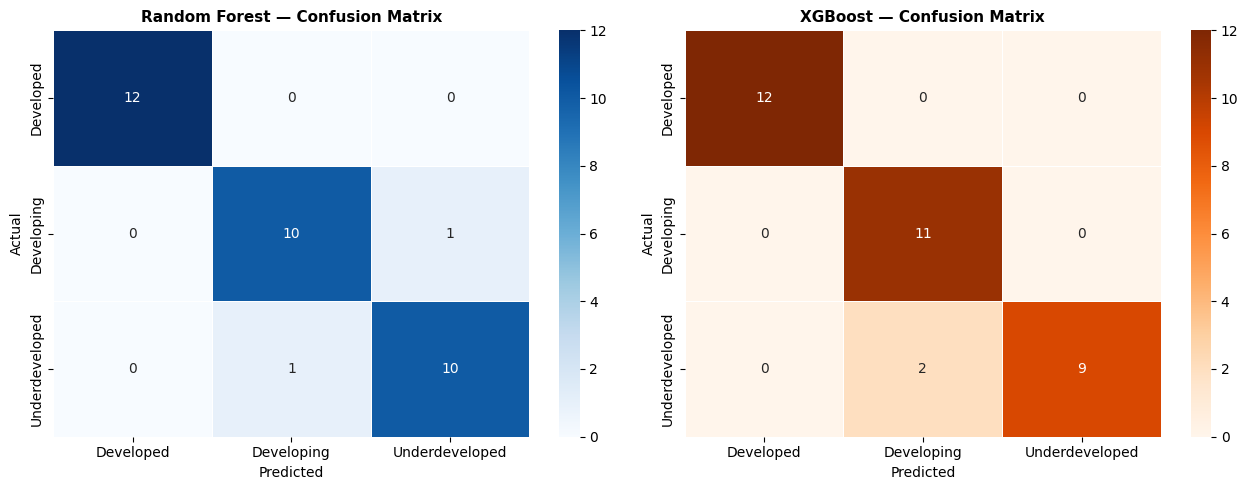

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, pred, title, cmap in zip(
    axes,
    [rf_pred, xgb_pred],
    ["Random Forest", "XGBoost"],
    ["Blues", "Oranges"]
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap=cmap,
                linewidths=0.5,
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    ax.set_title(f"{title} — Confusion Matrix", fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

        Model  Accuracy  ROC-AUC   CV-Acc
Random Forest  0.941176 0.993412 0.952050
      XGBoost  0.941176 1.000000 0.952228


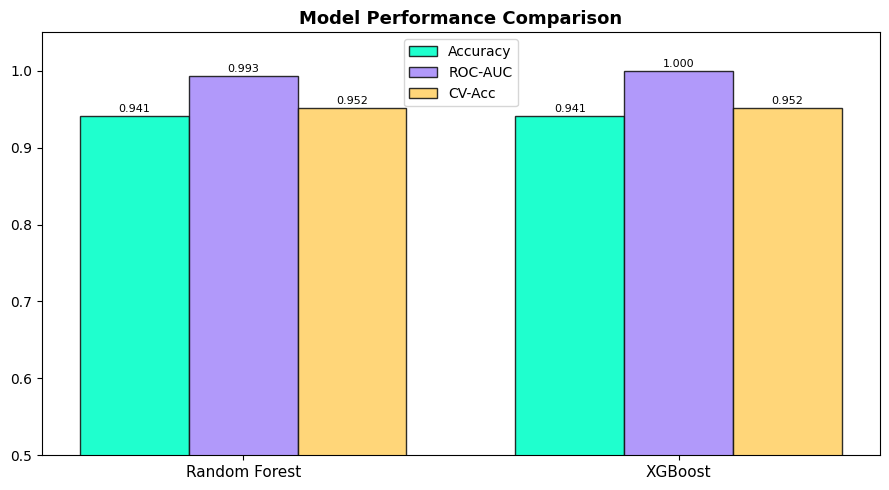

In [ ]:
metrics_df = pd.DataFrame({
    "Model":    ["Random Forest", "XGBoost"],
    "Accuracy": [rf_acc, xgb_acc],
    "ROC-AUC":  [rf_auc, xgb_auc],
    "CV-Acc":   [rf_cv,  xgb_cv],
})
print(metrics_df.to_string(index=False))

x = np.arange(2)
w = 0.25
colors = ["#00ffc8", "#a78bfa", "#ffd166"]

plt.figure(figsize=(9, 5))
for i, (metric, clr) in enumerate(zip(["Accuracy","ROC-AUC","CV-Acc"], colors)):
    bars = plt.bar(x + i*w, metrics_df[metric], width=w, label=metric,
                   color=clr, edgecolor="#111", alpha=0.88)
    for bar, val in zip(bars, metrics_df[metric]):
        plt.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f"{val:.3f}", ha="center", fontsize=8)

plt.xticks(x + w, metrics_df["Model"], fontsize=11)
plt.ylim(0.5, 1.05)
plt.legend()
plt.title("Model Performance Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

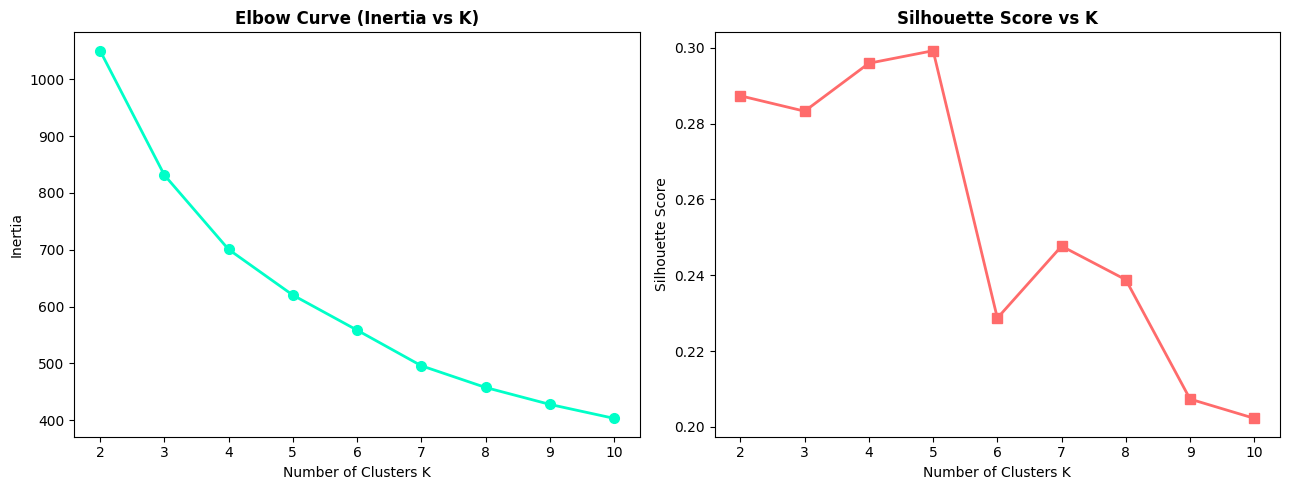

Optimal K based on Silhouette: 5


In [ ]:
inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(list(K_range), inertias, "o-", color="#00ffc8", lw=2, markersize=7)
ax1.set_title("Elbow Curve (Inertia vs K)", fontweight="bold")
ax1.set_xlabel("Number of Clusters K")
ax1.set_ylabel("Inertia")

ax2.plot(list(K_range), silhouettes, "s-", color="#ff6b6b", lw=2, markersize=7)
ax2.set_title("Silhouette Score vs K", fontweight="bold")
ax2.set_xlabel("Number of Clusters K")
ax2.set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

optimal_k = int(np.argmax(silhouettes)) + 2
print(f"Optimal K based on Silhouette: {optimal_k}")

In [ ]:
# ── FIT FINAL MODEL ───────────────────────────────────────
km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, km_labels)
print(f"Final K-Means Silhouette Score: {sil:.4f}")

# ── CLUSTER PROFILES ──────────────────────────────────────
df["kmeans_cluster"] = km_labels
cluster_profile = df.groupby("kmeans_cluster")[features].mean().round(2)
print("\nCluster Centroids (original scale):")
cluster_profile

Final K-Means Silhouette Score: 0.2993

Cluster Centroids (original scale):


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,21.61,40.98,6.17,47.52,12801.07,7.62,73.00,2.28,6581.81
1,90.79,29.66,6.46,43.68,3870.70,9.95,59.21,4.97,1900.26
2,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67
3,5.18,46.12,9.09,40.58,44021.88,2.51,80.08,1.79,42118.75
4,130.00,25.30,5.07,17.40,5150.00,104.00,60.50,5.84,2330.00


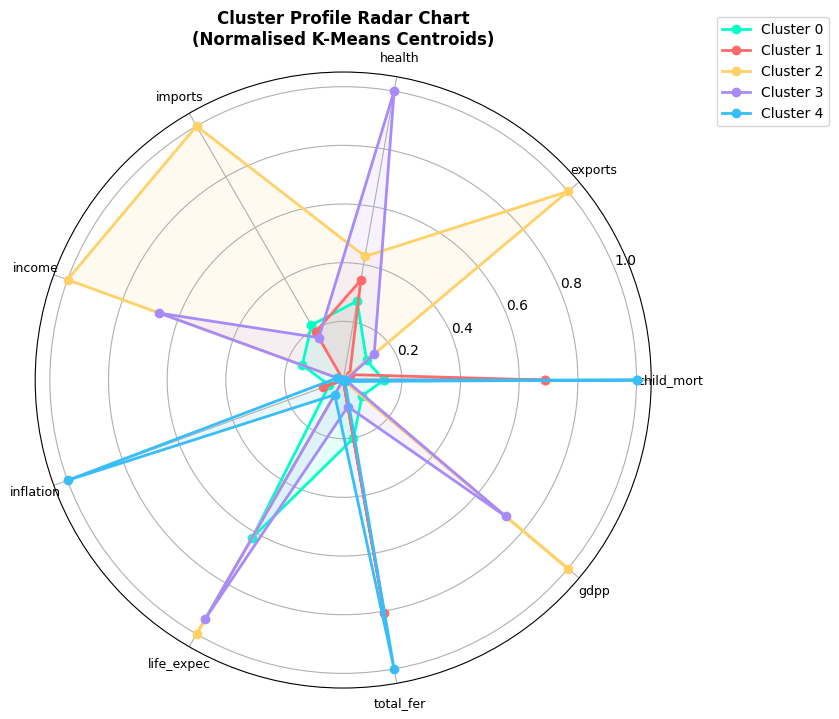

In [ ]:
# ── RADAR CHART ───────────────────────────────────────────
cluster_norm = (cluster_profile - cluster_profile.min()) / \
               (cluster_profile.max() - cluster_profile.min() + 1e-9)

angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]   # close the polygon

colors_radar = ["#00ffc8", "#ff6b6b", "#ffd166", "#a78bfa", "#38bdf8"]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})

for idx, (clust_id, row) in enumerate(cluster_norm.iterrows()):
    vals = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, vals, "o-", color=colors_radar[idx], lw=2,
            label=f"Cluster {clust_id}")
    ax.fill(angles, vals, alpha=0.1, color=colors_radar[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=9)
ax.set_title("Cluster Profile Radar Chart\n(Normalised K-Means Centroids)",
             fontsize=12, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()

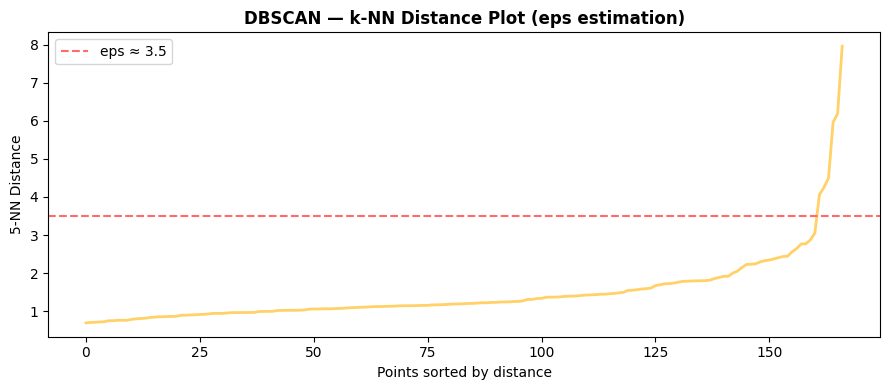

In [ ]:
# ── ESTIMATE eps VIA k-NN DISTANCE PLOT ───────────────────
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(9, 4))
plt.plot(k_dist, color="#ffd166", lw=2)
plt.axhline(y=3.5, color="#ff6b6b", linestyle="--", label="eps ≈ 3.5")
plt.title("DBSCAN — k-NN Distance Plot (eps estimation)", fontweight="bold")
plt.xlabel("Points sorted by distance")
plt.ylabel("5-NN Distance")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# DBSCAN
db = DBSCAN(eps=3.5, min_samples=5)
db_labels = db.fit_predict(X_scaled)
df["dbscan_cluster"] = db_labels

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = list(db_labels).count(-1)

print(f"DBSCAN Clusters Found : {n_clusters}")
print(f"Noise Points          : {n_noise}  ({100*n_noise/len(df):.1f}%)")
print(f"\nCluster label counts:\n{pd.Series(db_labels).value_counts().sort_index()}")

if n_clusters > 1:
    mask = db_labels != -1
    print(f"\nSilhouette Score (excl. noise): "
          f"{silhouette_score(X_scaled[mask], db_labels[mask]):.4f}")

DBSCAN Clusters Found : 1
Noise Points          : 4  (2.4%)

Cluster label counts:
-1      4
 0    163
Name: count, dtype: int64


Variance explained → PC1: 45.95%  |  PC2: 17.18%


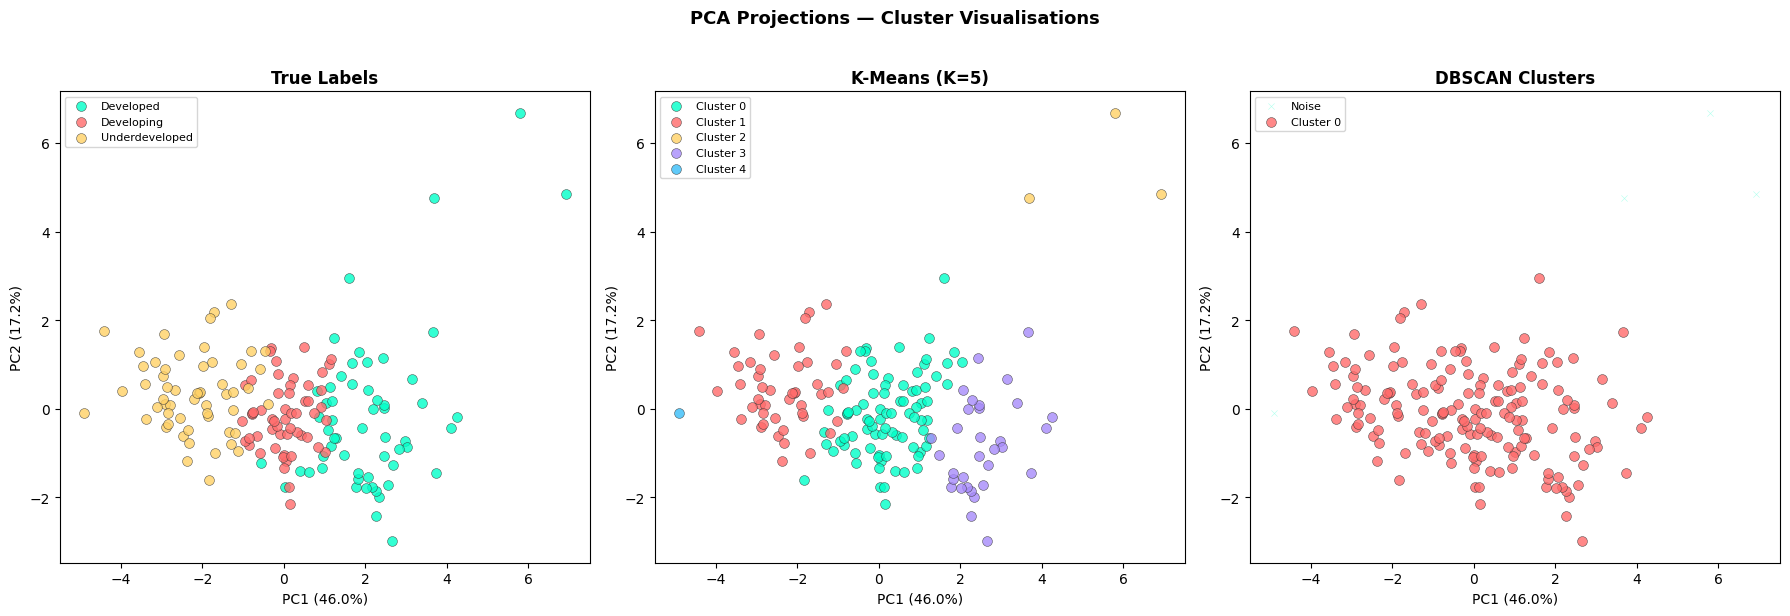

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
ev = pca.explained_variance_ratio_
print(f"Variance explained → PC1: {ev[0]:.2%}  |  PC2: {ev[1]:.2%}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors_pca = ["#00ffc8", "#ff6b6b", "#ffd166", "#a78bfa", "#38bdf8"]

# True labels
for cls, clr, lbl in zip(np.unique(y), colors_pca, le.classes_):
    mask = y == cls
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1], s=50, alpha=0.8,
                    color=clr, label=lbl, edgecolors="#333", lw=0.4)
axes[0].set_title("True Labels", fontweight="bold")
axes[0].legend(fontsize=8)

# K-Means clusters
for c in range(optimal_k):
    mask = km_labels == c
    axes[1].scatter(X_pca[mask,0], X_pca[mask,1], s=50, alpha=0.8,
                    color=colors_pca[c], label=f"Cluster {c}",
                    edgecolors="#333", lw=0.4)
axes[1].set_title(f"K-Means (K={optimal_k})", fontweight="bold")
axes[1].legend(fontsize=8)

# DBSCAN clusters
unique_db = sorted(set(db_labels))
for c, clr in zip(unique_db, colors_pca + ["#aaa"]):
    mask = db_labels == c
    lbl  = "Noise" if c == -1 else f"Cluster {c}"
    axes[2].scatter(X_pca[mask,0], X_pca[mask,1],
                    s=50 if c != -1 else 20,
                    alpha=0.8 if c != -1 else 0.3,
                    color=clr, label=lbl, edgecolors="#333", lw=0.4,
                    marker="o" if c != -1 else "x")
axes[2].set_title("DBSCAN Clusters", fontweight="bold")
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel(f"PC1 ({ev[0]:.1%})")
    ax.set_ylabel(f"PC2 ({ev[1]:.1%})")

fig.suptitle("PCA Projections — Cluster Visualisations",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 55)
print("        CUSTOMER INTELLIGENCE SYSTEM — SUMMARY")
print("=" * 55)
print(f"\n  Dataset       : {df.shape[0]} countries, {len(features)} features")
print(f"\n  ── CLASSIFICATION ──────────────────────────────")
print(f"  {'Model':<20} {'Accuracy':>9} {'ROC-AUC':>9} {'CV-Acc':>9}")
print(f"  {'-'*50}")
print(f"  {'Random Forest':<20} {rf_acc:>9.4f} {rf_auc:>9.4f} {rf_cv:>9.4f}")
print(f"  {'XGBoost':<20} {xgb_acc:>9.4f} {xgb_auc:>9.4f} {xgb_cv:>9.4f}")
print(f"\n  ── CLUSTERING ──────────────────────────────────")
print(f"  K-Means   → K={optimal_k}, Silhouette={silhouette_score(X_scaled, km_labels):.4f}")
print(f"  DBSCAN    → {n_clusters} cluster(s), {n_noise} noise points")
print(f"\n  ── TOP FEATURES (Random Forest) ────────────────")
top3 = pd.Series(rf.feature_importances_, index=features).nlargest(3)
for feat, imp in top3.items():
    print(f"  {feat:<15} importance = {imp:.4f}")
print("=" * 55)

        CUSTOMER INTELLIGENCE SYSTEM — SUMMARY

  Dataset       : 167 countries, 9 features

  ── CLASSIFICATION ──────────────────────────────
  Model                 Accuracy   ROC-AUC    CV-Acc
  --------------------------------------------------
  Random Forest           0.9412    0.9934    0.9520
  XGBoost                 0.9412    1.0000    0.9522

  ── CLUSTERING ──────────────────────────────────
  K-Means   → K=5, Silhouette=0.2993
  DBSCAN    → 1 cluster(s), 4 noise points

  ── TOP FEATURES (Random Forest) ────────────────
  child_mort      importance = 0.2982
  gdpp            importance = 0.2477
  income          importance = 0.1642
